In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from common.consts import long_to_short

# ---- you must already have y: Series indexed by shortnames (e.g., "D2A") ----
# y = ...  # log(WT MFPT / mutant MFPT)

def read_colvar_with_fields(path: Path) -> pd.DataFrame:
    with path.open() as f:
        header = next(line for line in f if line.startswith("#!"))
    names = header.strip().split()[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

# ---- config ----
wt = "chignolin"
rmsd_threshold = 0.15
eps = 1e-12

target_metric = "sum_delta"  # change to any computed metric below

# ---- load WT once ----
wt_path = Path(f"../data/{wt}/output/run_000/COLVAR_000")
df_wt = read_colvar_with_fields(wt_path)
descriptors = [c for c in df_wt.columns if c.startswith("d")]

# Pre-filter WT folded frames (we'll sub-sample by fraction later)
df_wt_folded = df_wt[df_wt["rmsd"] < rmsd_threshold].reset_index(drop=True)

# ---- list of mutants (long names); make sure WT (chignolin) is not in the loop ----
proteins = [p for p in long_to_short.keys() if p != wt]

def compute_stats_at_fraction(frac: float) -> pd.DataFrame:
    """
    Use only the first `frac` fraction of folded frames for WT and each mutant.
    Returns DataFrame indexed by shortnames with all stats (incl. sum_delta).
    """
    # WT subset
    n_wt = max(5, int(len(df_wt_folded) * frac))  # keep at least a few frames
    df_wt_sub = df_wt_folded.iloc[:n_wt]
    var_wt = df_wt_sub[descriptors].var(ddof=1)
    mu_wt = df_wt_sub[descriptors].mean()

    # Precompute WT per-descriptor arrays and q90 thresholds
    vals_wt = {d: df_wt_sub[d].to_numpy() for d in descriptors}
    q90_wt = {d: np.quantile(vals_wt[d], 0.90) for d in descriptors}

    rows, idx = [], []
    for protein in proteins:
        # read mutant
        path = Path(f"../data/{protein}/output/run_000/COLVAR_000")
        df = read_colvar_with_fields(path)
        df_filt = df[df["rmsd"] < rmsd_threshold].reset_index(drop=True)
        if len(df_filt) < 5:
            continue

        # mutant subset
        n_mut = max(5, int(len(df_filt) * frac))
        df_mut_sub = df_filt.iloc[:n_mut]

        var_mut = df_mut_sub[descriptors].var(ddof=1)
        mu_mut = df_mut_sub[descriptors].mean()
        vals_mut = {d: df_mut_sub[d].to_numpy() for d in descriptors}

        # variance-based deltas
        delta = var_wt - var_mut
        abs_delta = delta.abs()
        rel_delta = delta / var_wt.replace(0, pd.NA)

        # 1) mean_abs_rel_mean_shift
        rel_mean_shift = ((mu_mut - mu_wt) / (mu_wt.replace(0, np.nan))).abs()
        mean_abs_rel_mean_shift = float(np.nanmean(rel_mean_shift.to_numpy()))

        # 2) tail_prob_inc_90
        tail_diffs = []
        for d in descriptors:
            thr = q90_wt[d]
            vm = vals_mut[d]; vw = vals_wt[d]
            pm = np.mean(vm > thr) if len(vm) else np.nan
            pw = np.mean(vw > thr) if len(vw) else np.nan
            tail_diffs.append(pm - pw)
        tail_prob_inc_90 = float(np.nanmean(tail_diffs))

        # 3) cos_mean_profile
        num = float(np.dot(mu_wt.to_numpy(), mu_mut.to_numpy()))
        den = float(np.linalg.norm(mu_wt.to_numpy()) * np.linalg.norm(mu_mut.to_numpy()) + eps)
        cos_mean_profile = num / den

        out = {
            "sum_delta": delta.sum(),
            "sum_abs_delta": abs_delta.sum(),
            "mean_abs_delta": abs_delta.mean(),
            "mean_rel_delta": rel_delta.mean(skipna=True),
            "var_corr": var_wt.corr(var_mut),
            "delta_total_var": var_wt.sum() - var_mut.sum(),
            "mean_abs_rel_mean_shift": mean_abs_rel_mean_shift,
            "tail_prob_inc_90": tail_prob_inc_90,
            "cos_mean_profile": cos_mean_profile,
        }

        rows.append(out)
        idx.append(long_to_short.get(protein, protein))  # short name

    res = pd.DataFrame(rows, index=idx)
    # drop WT shortname if present
    res = res.drop(index=["WT"], errors="ignore")
    return res


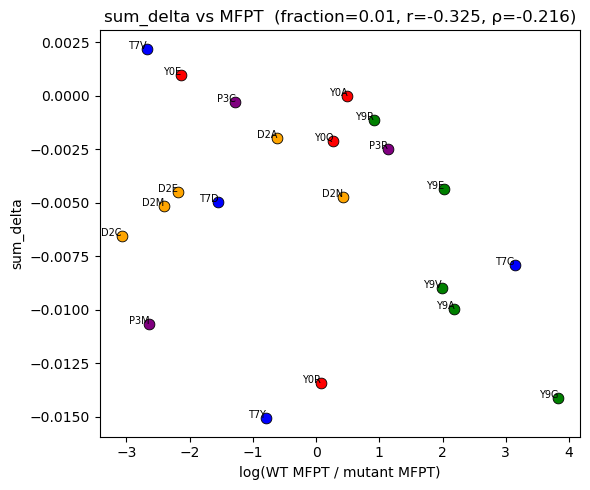

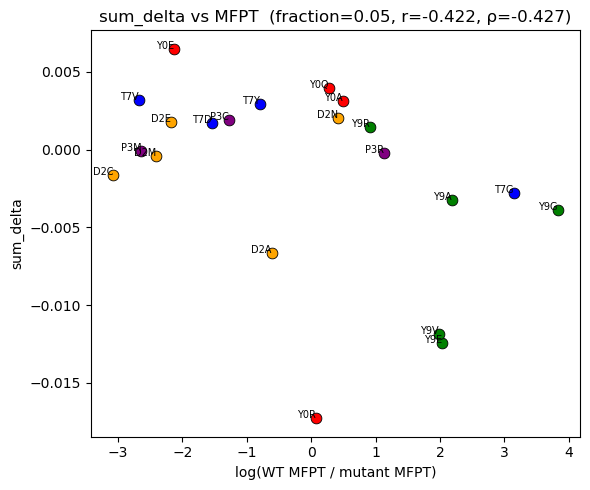

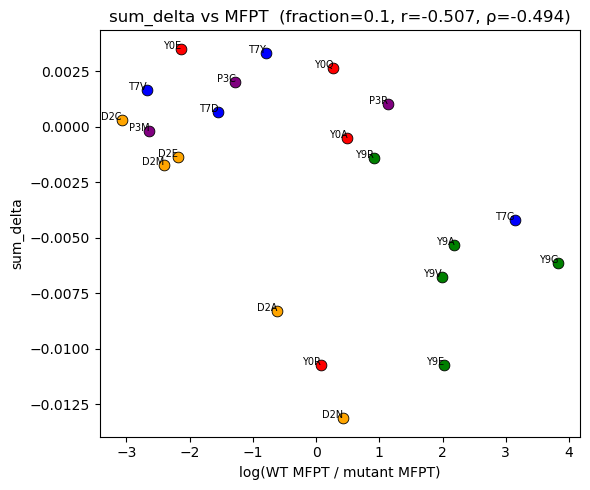

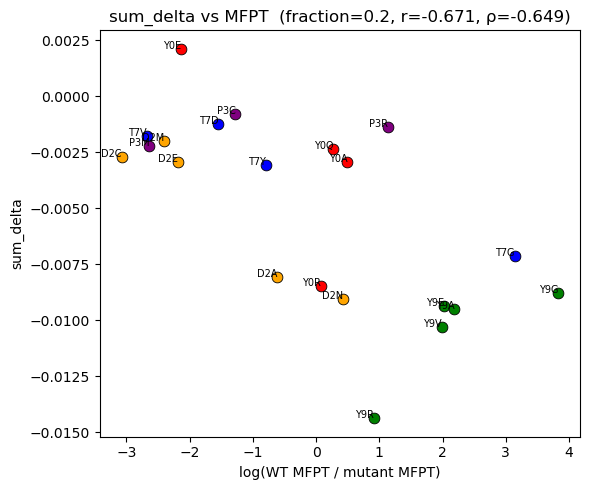

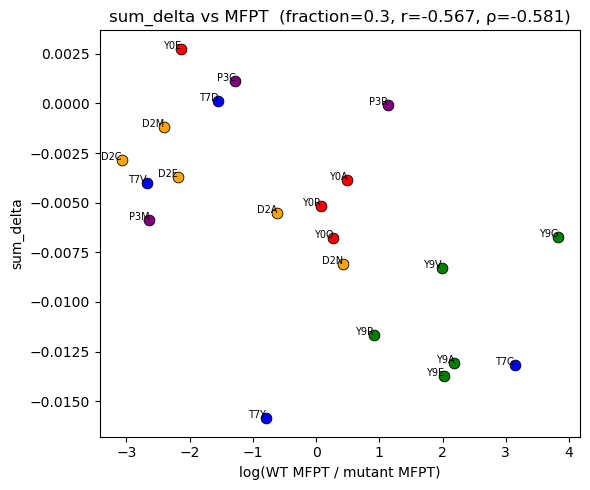

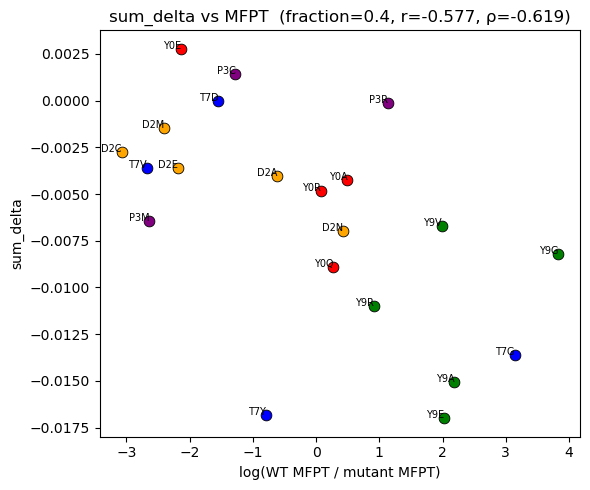

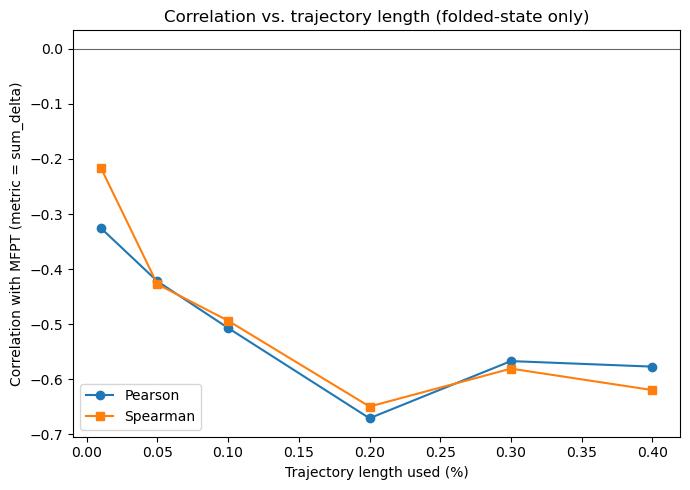

In [ ]:
from scipy.stats import pearsonr, spearmanr
from common.utils import collect_df
from common.consts import res_colors
import numpy as np
import pickle
import matplotlib.pyplot as plt
import re

# ---- load MFPT ----
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(True, all_mfpt, thresholds[1])
mfpt = df['mfpt']
y = np.log(mfpt['WT'] / mfpt.drop(labels=["WT"], errors="ignore"))

exclude = ["Y9Q", "D2R", "T7Q", "WT", "P3D", "T7R"]
y_short = y.copy().drop(index=exclude, errors="ignore")

fractions = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
target_metric = "sum_delta"

pearsons, spearmans = [], []

def get_res_idx(mut):
    m = re.search(r"(\d+)", mut)
    return int(m.group(1)) if m else None

for f in fractions:
    res_f = compute_stats_at_fraction(f).drop(index=exclude, errors="ignore")

    # align to y
    common = res_f.index.intersection(y_short.index)
    if len(common) < 3:
        pearsons.append(np.nan); spearmans.append(np.nan)
        continue

    x = res_f.loc[common, target_metric].astype(float).values
    yy = y_short.loc[common].astype(float).values

    mask = np.isfinite(x) & np.isfinite(yy)
    if mask.sum() < 3:
        pearsons.append(np.nan); spearmans.append(np.nan)
        continue

    pr, _ = pearsonr(x[mask], yy[mask])
    sr, _ = spearmanr(x[mask], yy[mask])
    pearsons.append(pr); spearmans.append(sr)

    # ---- scatter plot for this fraction ----
    plt.figure(figsize=(6,5))
    for mut in common:
        color = res_colors.get(get_res_idx(mut), "gray")
        plt.scatter(y_short.loc[mut], res_f.loc[mut, target_metric],
                    color=color, s=60, edgecolors="k", linewidths=0.6)
        plt.text(y_short.loc[mut], res_f.loc[mut, target_metric], mut,
                 fontsize=7, ha="right")
    plt.xlabel("log(WT MFPT / mutant MFPT)")
    plt.ylabel(target_metric)
    plt.title(f"{target_metric} vs MFPT  (fraction={f:.3g}, r={pr:.3g}, ρ={sr:.3g})")
    plt.tight_layout()
    plt.show()

# ---- summary plot of correlation vs fraction ----
plt.figure(figsize=(7,5))
plt.plot(fractions, pearsons, marker="o", label="Pearson")
plt.plot(fractions, spearmans, marker="s", label="Spearman")
plt.axhline(0, color="k", lw=0.8, alpha=0.6)
plt.xlabel("Trajectory length used (%)")
plt.ylabel(f"Correlation with MFPT (metric = {target_metric})")
plt.title("Correlation vs. trajectory length (folded-state only)")
plt.legend()
plt.tight_layout()
plt.show()
